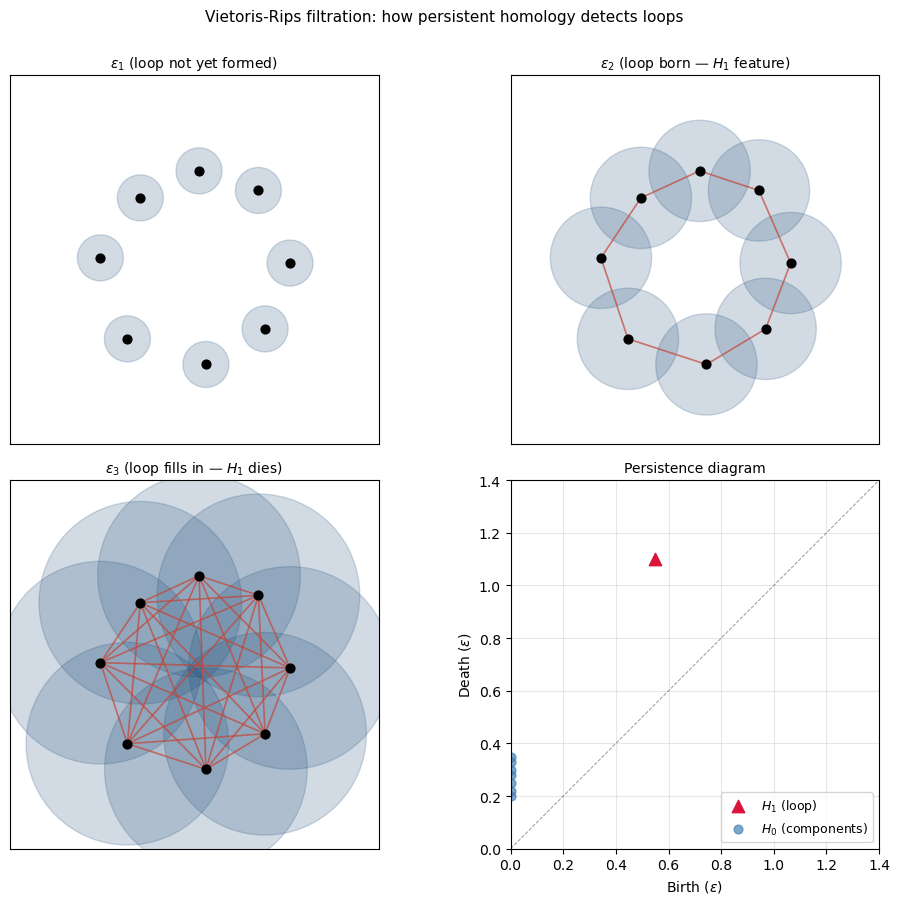

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Toy point cloud: 8 points roughly on a circle, which will form a loop
np.random.seed(42)
n_points = 8
angles = np.linspace(0, 2*np.pi, n_points, endpoint=False)
radius = 1.0
noise = 0.08
points = np.column_stack([
    radius * np.cos(angles) + np.random.randn(n_points) * noise,
    radius * np.sin(angles) + np.random.randn(n_points) * noise
])

# Three filtration scales to show the loop being born, persisting, and dying
scales = [0.25, 0.55, 1.10]
scale_labels = [r'$\epsilon_1$ (loop not yet formed)',
                r'$\epsilon_2$ (loop born — $H_1$ feature)',
                r'$\epsilon_3$ (loop fills in — $H_1$ dies)']

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

# Flatten so we can index 0, 1, 2, 3
ax_list = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]

# Three filtration panels (top-left, top-right, bottom-left)
for ax, eps, label in zip(ax_list[:3], scales, scale_labels):
    for p in points:
        circle = Circle(p, eps, alpha=0.2, color='#1f4e79', zorder=1)
        ax.add_patch(circle)
    for i in range(n_points):
        for j in range(i+1, n_points):
            d = np.linalg.norm(points[i] - points[j])
            if d <= 2 * eps:
                ax.plot([points[i, 0], points[j, 0]],
                        [points[i, 1], points[j, 1]],
                        color='#c44536', lw=1.2, alpha=0.7, zorder=2)
    ax.scatter(points[:, 0], points[:, 1], c='black', s=40, zorder=3)
    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
    ax.set_aspect('equal'); ax.set_title(label, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks([]); ax.set_yticks([])

# Persistence diagram (bottom-right)
ax = ax_list[3]
ax.scatter([scales[1]], [scales[2]], c='crimson', s=80, marker='^',
           label=r'$H_1$ (loop)', zorder=3)
h0_deaths = [0.20, 0.22, 0.25, 0.28, 0.30, 0.33, 0.35]
ax.scatter([0]*len(h0_deaths), h0_deaths, c='steelblue', s=40,
           label=r'$H_0$ (components)', alpha=0.7, zorder=2)
ax.plot([0, 1.4], [0, 1.4], 'k--', alpha=0.4, lw=0.7)
ax.set_xlim(0, 1.4); ax.set_ylim(0, 1.4)
ax.set_xlabel(r'Birth ($\epsilon$)'); ax.set_ylabel(r'Death ($\epsilon$)')
ax.set_title('Persistence diagram', fontsize=10)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3); ax.set_aspect('equal')

plt.suptitle('Vietoris-Rips filtration: how persistent homology detects loops',
             y=1.00, fontsize=11)
plt.tight_layout()
plt.savefig('fig3_filtration.png', dpi=200, bbox_inches='tight')
plt.show()